---
numbering: false
---

# 2.3: Orthogonal projections

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'
ANNOTATION_SIZE = 24


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0, color='black'):
    # MathJax needs its own size command when exporting math labels to PNG.
    if label.startswith('$') and label.endswith('$'):
        label = r'$\Large ' + label[1:]
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(family='Palatino', color=color, size=ANNOTATION_SIZE))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, '$' + label.replace('−', '-') + '$', dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.3, dy=0.3, width=4):
    # Match Chapter 1.4: a colored shaft, arrowhead, and midpoint math label.
    line2(fig, start, end, color=color, width=width)
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.2, arrowwidth=3, arrowcolor=color)
    if label:
        midpoint = (np.asarray(start, dtype=float) + np.asarray(end, dtype=float)) / 2
        label2(fig, midpoint, label, dx, dy, color=color)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)

In [Chapter 2.2](02-02.ipynb), we used an orthonormal basis to split a vector into two perpendicular components. Now let's focus on the component along a given line. This will let us answer questions such as: how much of a vehicle's weight pulls it down a ramp?

## Decomposing a vector into perpendicular components

Let $\ell$ be a line through the origin, and let $\vec w$ be a vector in $\mathbb R^2$. We can split $\vec w$ into two components:

$$\vec w=\vec w_{\parallel}+\vec w_{\perp},$$

where $\vec w_{\parallel}$ lies along $\ell$ and $\vec w_{\perp}$ is perpendicular to $\ell$.

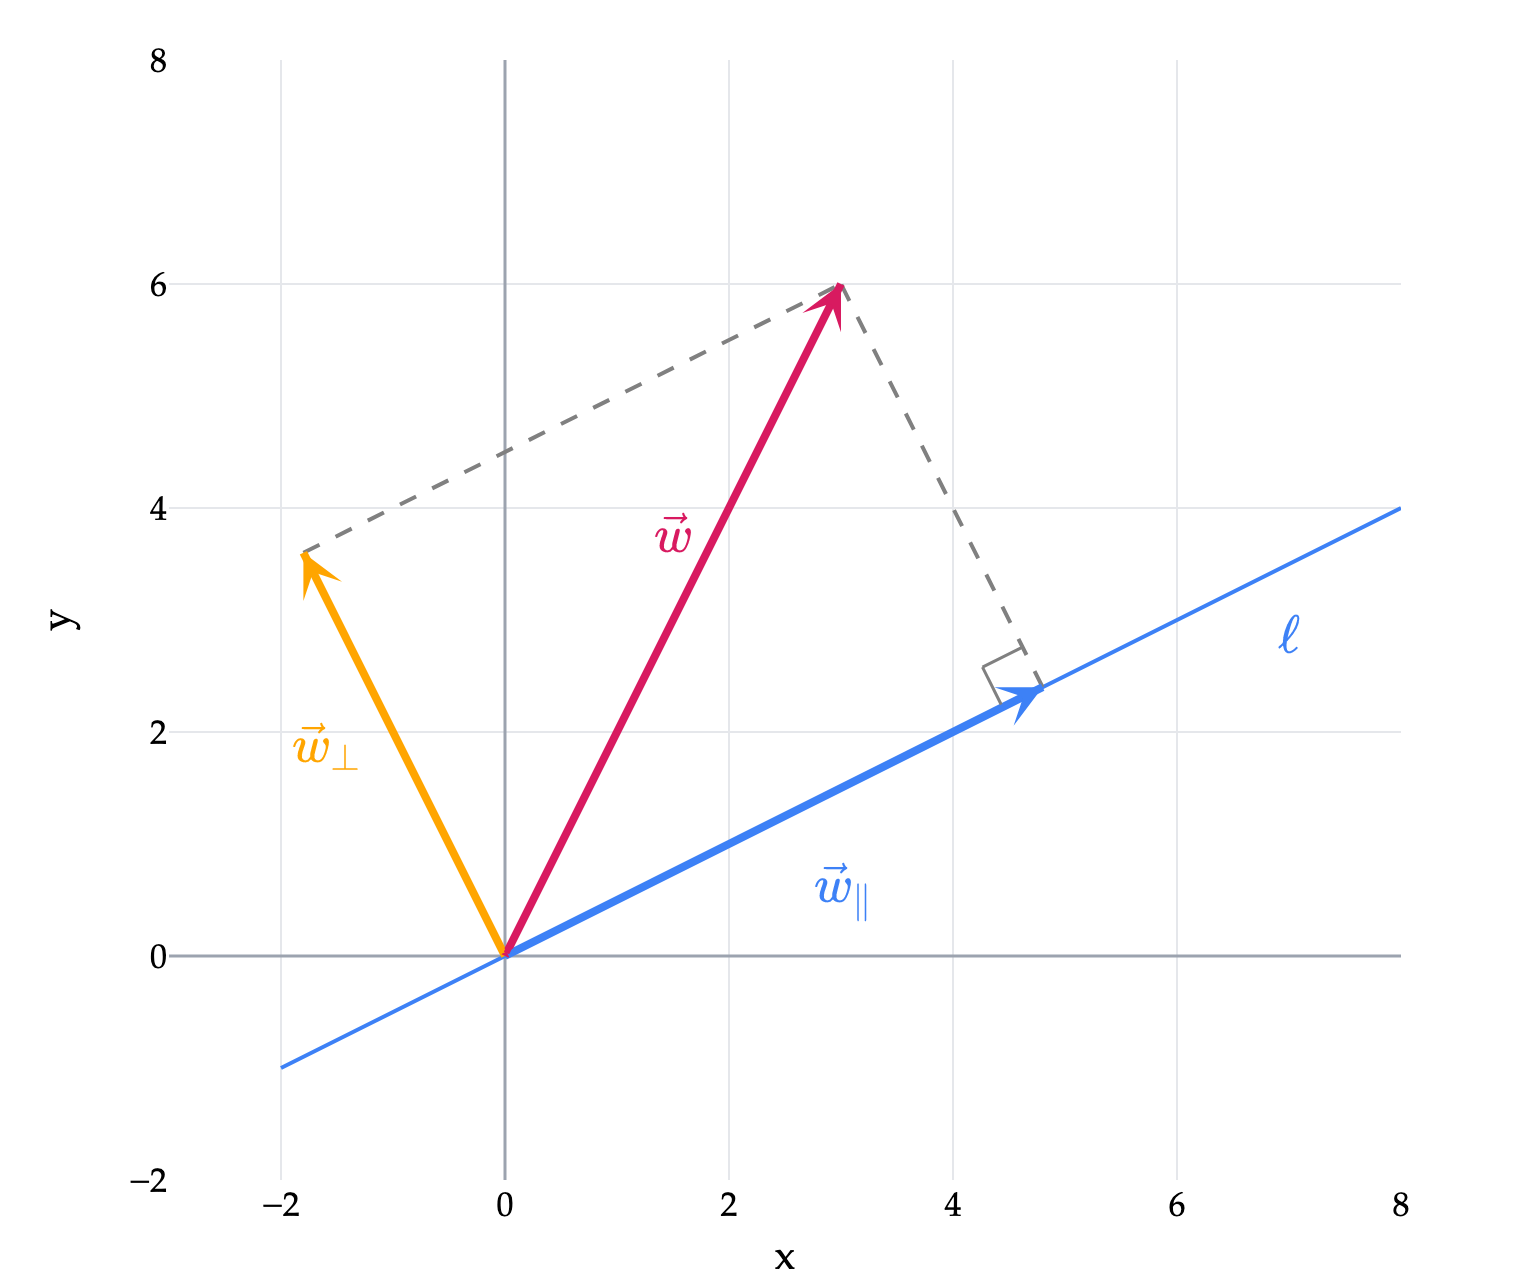

In [2]:
fig=base2((-3, 8), (-2, 8), width=760,height=640,tick=2)
w=np.array([3, 6]); direction=np.array([2, 1])
p=(w@direction)/(direction@direction)*direction; q=w-p
line2(fig,-direction,4*direction,BLUE)
line2(fig,p,w,'gray','dash'); line2(fig,q,w,'gray','dash')
vec2(fig,p,r'$\vec w_{\parallel}$',BLUE,dx=0.6,dy=-0.6)
vec2(fig,q,r'$\vec w_{\perp}$',ORANGE,dx=-0.7,dy=0.1)
vec2(fig,w,r'$\vec w$',PINK,dx=0.0,dy=0.8)
square2(fig,p,-direction,q,0.4)
label2(fig,3.5*direction,r'$\ell$',dy=-0.6,color=BLUE)
fig.show(scale=2)

```{figure} #plot-23-decomposition
:label: fig-plot-23-decomposition
:class: course-caption
:alt: The blue and orange components add to the original vector, shown in pink.

The blue and orange components add to the original vector, shown in pink.
```

:::{note} Definition: Orthogonal projection onto a line
Let $\ell$ be a line through the origin. The **orthogonal projection** of $\vec w$ onto $\ell$, written $\operatorname{proj}_{\ell}(\vec w)$, is the unique vector along $\ell$ for which $\vec w-\operatorname{proj}_{\ell}(\vec w)$ is perpendicular to $\ell$.
:::

So $\vec w_{\parallel}=\operatorname{proj}_{\ell}(\vec w)$. Here, $\ell^\perp$ is the line of vectors orthogonal to every vector on $\ell$. We use this notation for a line **through the origin**.


Move the slider below to choose a vector $t\vec v_1$ along $\ell$, where

$$\vec w=\begin{bmatrix}8\\9\end{bmatrix},\qquad \vec v_1=\begin{bmatrix}3\\2\end{bmatrix},\qquad \ell:2x-3y=0.$$

The chosen vector and its **error**, drawn from its tip to the tip of $\vec w$, always add to $\vec w$:

$$t\vec v_1+(\vec w-t\vec v_1)=\vec w.$$

**Which choice makes the error perpendicular to $\ell$?** At that position, the chosen vector is the projection $\vec w_{\parallel}$, and the error is the perpendicular component $\vec w_{\perp}$.


In [3]:
# Move a candidate along the line while keeping candidate + error = original.
slider_w = np.array([8., 9.])
slider_v1 = np.array([3., 2.])
projection_t = float(slider_w @ slider_v1 / (slider_v1 @ slider_v1))
slider_values = sorted(set([round(float(t), 2) for t in np.linspace(-1, 5, 121)]
                           + [projection_t]))


def projection_slider_state(t):
    candidate = t * slider_v1
    error = slider_w - candidate
    at_projection = t == projection_t
    traces = []
    for start, end, color, name in [
        (np.zeros(2), candidate, BLUE, 'Projection' if at_projection else 'Candidate'),
        (candidate, slider_w, ORANGE, 'Perpendicular component' if at_projection else 'Error'),
        (np.zeros(2), slider_w, PINK, 'Original')]:
        traces.append(go.Scatter(
            x=[float(start[0]), float(end[0])], y=[float(start[1]), float(end[1])],
            mode='lines+markers', line=dict(color=color, width=4),
            marker=dict(size=[0, 14], symbol='arrow', angleref='previous', color=color),
            name=name, hoverinfo='name', showlegend=False))
    # Keep a fixed trace count so the right-angle marker disappears when moving away.
    if at_projection:
        along = -slider_v1 / np.linalg.norm(slider_v1) * 0.5
        normal = error / np.linalg.norm(error) * 0.5
        square = np.array([candidate + along, candidate + along + normal, candidate + normal])
        sx, sy = square[:, 0].tolist(), square[:, 1].tolist()
    else:
        sx, sy = [], []
    traces.append(go.Scatter(x=sx, y=sy, mode='lines', line=dict(color='gray', width=2),
                             hoverinfo='skip', showlegend=False))
    labels = [
        dict(x=float(candidate[0]/2), y=float(candidate[1]/2), yshift=-28,
             text='<b>w</b><sub>∥</sub> = proj<sub>ℓ</sub>(<b>w</b>)' if at_projection else 't <b>v</b><sub>1</sub>',
             font=dict(color=BLUE, size=20)),
        dict(x=float((candidate[0]+slider_w[0])/2), y=float((candidate[1]+slider_w[1])/2),
             xshift=55, text='<b>w</b><sub>⊥</sub>' if at_projection else '<b>w</b> − t <b>v</b><sub>1</sub>',
             font=dict(color=ORANGE, size=20)),
        dict(x=3.1, y=5.2, text='<b>w</b>', font=dict(color=PINK, size=20)),
        dict(x=14.5, y=9, text='ℓ', font=dict(color=BLUE, size=20)),
        dict(x=0.5, y=1.12, xref='paper', yref='paper',
             text='Projection + perpendicular component = original' if at_projection
                  else 'Candidate + error = original', font=dict(size=18)),
        dict(x=0.5, y=1.04, xref='paper', yref='paper',
             text='Error is perpendicular to ℓ' if at_projection else 'Move t until the error is perpendicular to ℓ',
             font=dict(size=16))]
    for label in labels:
        label['showarrow'] = False
    return dict(data=traces, traces=[1, 2, 3, 4], layout=dict(annotations=labels))


projection_slider = base2((-4, 17), (-4, 13), width=660, height=660, tick=2)
projection_slider.update_layout(margin=dict(l=55, r=35, t=105, b=135))
line2(projection_slider, (-6, -4), (18, 12), BLUE, width=1.5)
initial_state = projection_slider_state(2.)
projection_slider.add_traces(initial_state['data'])
projection_slider.update_layout(**initial_state['layout'])
projection_slider.frames = [go.Frame(name=f'projection-{i}', **projection_slider_state(t))
                            for i, t in enumerate(slider_values)]
instant = dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))
projection_slider.update_layout(sliders=[dict(
    active=slider_values.index(2.), x=0.12, len=0.76, y=-0.09,
    currentvalue=dict(prefix='t = ', font=dict(size=18)), pad=dict(t=15), ticklen=0,
    steps=[dict(method='animate', label='42/13' if t == projection_t else f'{t:g}',
                args=[[f'projection-{i}'], instant]) for i, t in enumerate(slider_values)])])
projection_slider.show(renderer='plotly_mimetype')


*The blue vector and orange error always add to the pink original vector. At $t=42/13$, they are the perpendicular components $\vec w_{\parallel}$ and $\vec w_{\perp}$.*



---

## Finding the projection using a unit vector

Choose a unit vector $\vec u_1$ along $\ell$ and a unit vector $\vec u_2$ perpendicular to $\ell$. Together, they form an orthonormal basis. By [Chapter 2.2](02-02.ipynb),

$$\vec w=(\vec w\cdot\vec u_1)\vec u_1+(\vec w\cdot\vec u_2)\vec u_2.$$

The first term lies along $\ell$, and the second is perpendicular to $\ell$. This identifies the projection:

:::{note} Projection using a unit vector
For a unit vector $\vec u_1$ along $\ell$,

$$\operatorname{proj}_{\ell}(\vec w)=(\vec w\cdot\vec u_1)\vec u_1.$$

The dot product is a scalar. Multiplying it by $\vec u_1$ gives the projected vector.
:::

### Projecting onto $2x-3y=0$

Let's project $\vec w=\begin{bmatrix}8\\9\end{bmatrix}$ onto $\ell:2x-3y=0$.

A direction vector along $\ell$ is $\vec v_1=\begin{bmatrix}3\\2\end{bmatrix}$, since $2(3)-3(2)=0$. Its length is $\sqrt{3^2+2^2}=\sqrt{13}$, so a unit vector along $\ell$ is

$$\vec u_1=\frac{\vec v_1}{\lVert\vec v_1\rVert}=\begin{bmatrix}3/\sqrt{13}\\2/\sqrt{13}\end{bmatrix}.$$

First, take the dot product:

$$\vec w\cdot\vec u_1=8\left(\frac3{\sqrt{13}}\right)+9\left(\frac2{\sqrt{13}}\right)=\frac{42}{\sqrt{13}}.$$

Then multiply by the unit vector:

$$\operatorname{proj}_{\ell}(\vec w)=\frac{42}{\sqrt{13}}\begin{bmatrix}3/\sqrt{13}\\2/\sqrt{13}\end{bmatrix}=\begin{bmatrix}126/13\\84/13\end{bmatrix}.$$

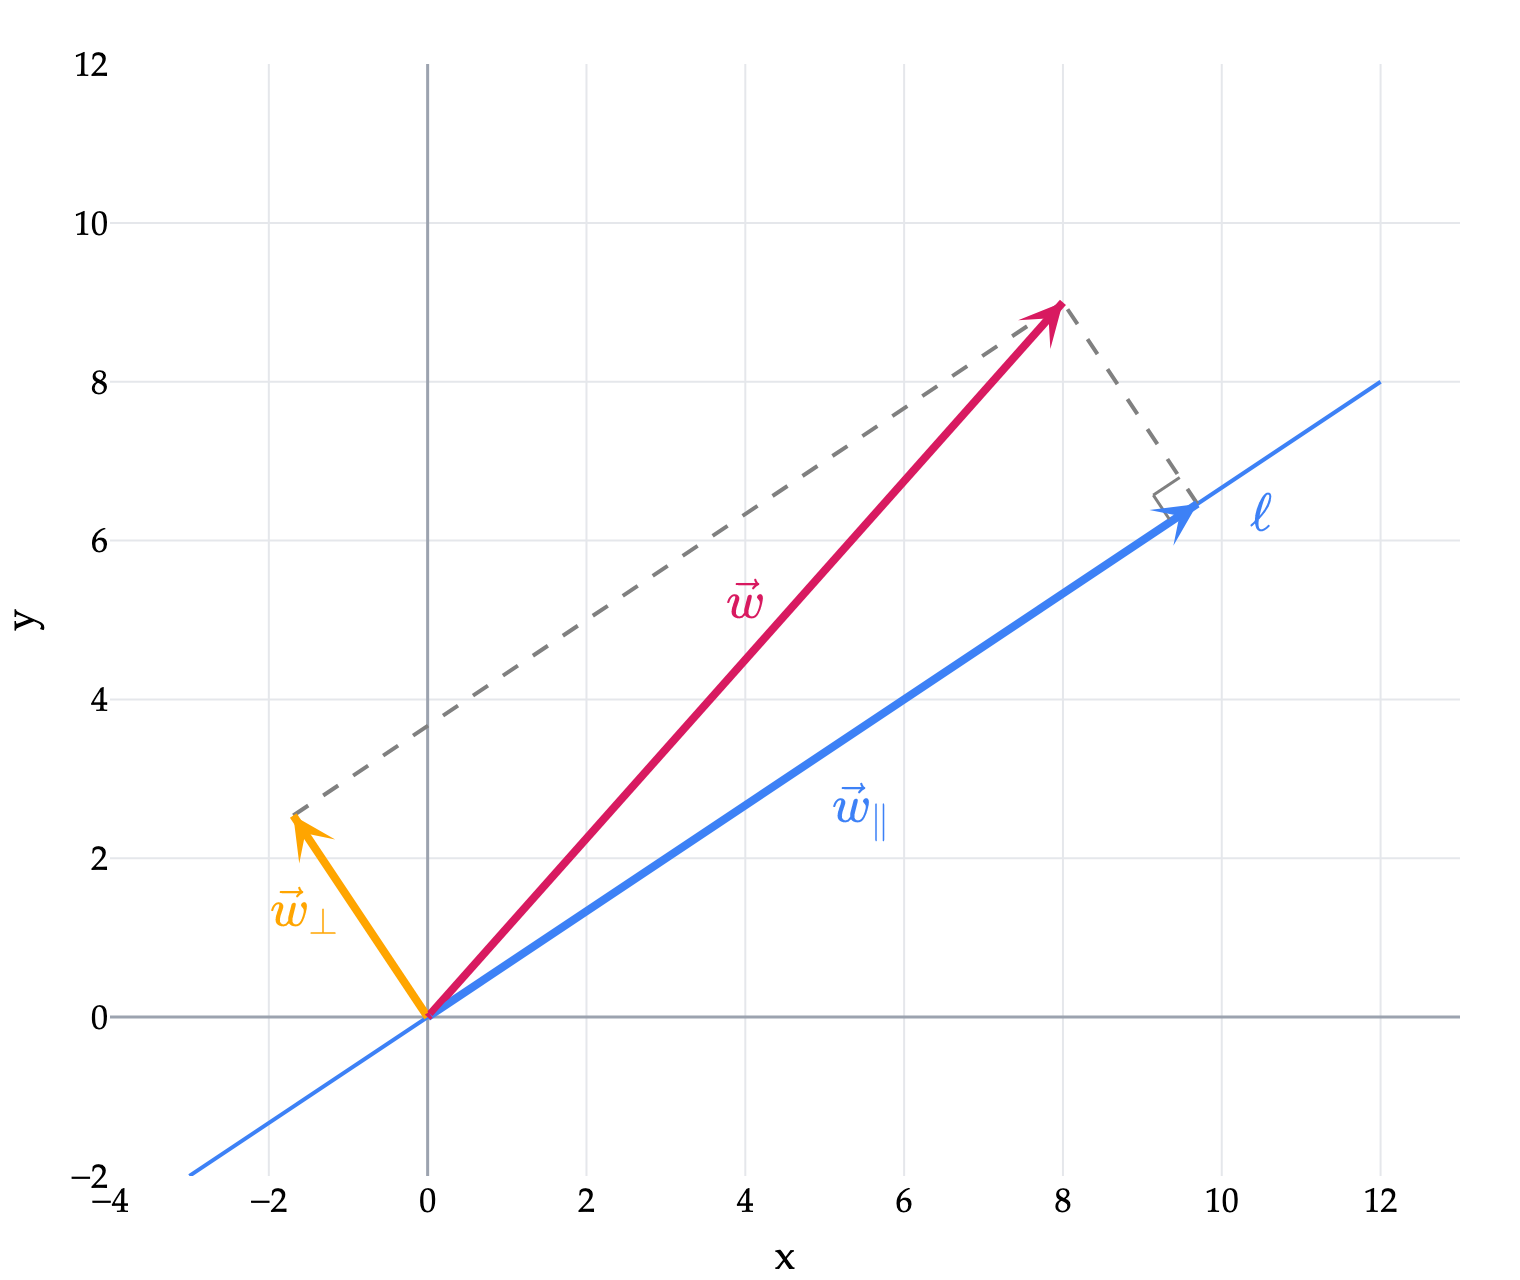

In [4]:
fig=base2((-4, 13), (-2, 12), width=760,height=640,tick=2)
w=np.array([8, 9]); direction=np.array([3, 2])
p=(w@direction)/(direction@direction)*direction; q=w-p
line2(fig,-direction,4*direction,BLUE)
line2(fig,p,w,'gray','dash'); line2(fig,q,w,'gray','dash')
vec2(fig,p,r'$\vec w_{\parallel}$',BLUE,dx=0.6,dy=-0.6)
vec2(fig,q,r'$\vec w_{\perp}$',ORANGE,dx=-0.7,dy=0.1)
vec2(fig,w,r'$\vec w$',PINK,dx=0.0,dy=0.8)
square2(fig,p,-direction,q,0.4)
label2(fig,3.5*direction,r'$\ell$',dy=-0.6,color=BLUE)
fig.show(scale=2)

```{figure} #plot-23-example
:label: fig-plot-23-example
:class: course-caption
:alt: The projection of $\vec w=\begin{bmatrix}8\\9\end{bmatrix}$ onto $2x-3y=0$ is $\vec w_{\parallel}=\begin{bmatrix}126/13\\84/13\end{bmatrix}$.

The projection of $\vec w=\begin{bmatrix}8\\9\end{bmatrix}$ onto $2x-3y=0$ is $\vec w_{\parallel}=\begin{bmatrix}126/13\\84/13\end{bmatrix}$.
```

---

## Finding the projection without normalizing

The square roots canceled in the final answer. Can we avoid introducing them in the first place?

Let $\vec v_1$ be **any nonzero vector along $\ell$**. Substituting $\vec u_1=\vec v_1/\lVert\vec v_1\rVert$ into the unit-vector formula gives

$$\begin{aligned}
\operatorname{proj}_{\ell}(\vec w)
&=\left(\vec w\cdot\frac{\vec v_1}{\lVert\vec v_1\rVert}\right)\frac{\vec v_1}{\lVert\vec v_1\rVert}\\
&=\frac{\vec w\cdot\vec v_1}{\lVert\vec v_1\rVert^2}\vec v_1\\
&=\frac{\vec w\cdot\vec v_1}{\vec v_1\cdot\vec v_1}\vec v_1.
\end{aligned}$$

:::{note} Projection using any nonzero direction vector
If $\ell=\operatorname{span}(\vec v_1)$ and $\vec v_1\ne\vec0$, then

$$\operatorname{proj}_{\ell}(\vec w)=\frac{\vec w\cdot\vec v_1}{\vec v_1\cdot\vec v_1}\vec v_1.$$

The vector $\vec v_1$ does not need to have length one. Its squared length in the denominator accounts for its scale.
:::

Let's check this in the same example, using $\vec w=\begin{bmatrix}8\\9\end{bmatrix}$ and $\vec v_1=\begin{bmatrix}3\\2\end{bmatrix}$:

$$\begin{aligned}
\operatorname{proj}_{\ell}(\vec w)
&=\frac{8(3)+9(2)}{3^2+2^2}\begin{bmatrix}3\\2\end{bmatrix}\\
&=\frac{42}{13}\begin{bmatrix}3\\2\end{bmatrix}\\
&=\begin{bmatrix}126/13\\84/13\end{bmatrix}.
\end{aligned}$$

This is exactly the result we found using a unit vector. This formula usually makes the computation easier: we can skip normalization, so the square roots it introduces typically go away. Any nonzero multiple of $\vec v_1$ gives the same projection, even if it points in the opposite direction.

---

## Finding the perpendicular component

Once we know the projection, we can find the other component by subtraction:

$$\vec w_{\perp}=\vec w-\operatorname{proj}_{\ell}(\vec w).$$

In our example,

$$\vec w_{\perp}=\begin{bmatrix}8\\9\end{bmatrix}-\begin{bmatrix}126/13\\84/13\end{bmatrix}=\begin{bmatrix}-22/13\\33/13\end{bmatrix}.$$

This vector is perpendicular to the line because its dot product with the direction vector is zero:

$$\begin{bmatrix}-22/13\\33/13\end{bmatrix}\cdot\begin{bmatrix}3\\2\end{bmatrix}=\frac{-66+66}{13}=0.$$

The components also add back to the original vector:

$$\begin{bmatrix}126/13\\84/13\end{bmatrix}+\begin{bmatrix}-22/13\\33/13\end{bmatrix}=\begin{bmatrix}8\\9\end{bmatrix}.$$

We could also project directly onto $\ell^\perp$. A unit vector along it is $\vec u_2=\begin{bmatrix}-2/\sqrt{13}\\3/\sqrt{13}\end{bmatrix}$, so

$$\operatorname{proj}_{\ell^\perp}(\vec w)=\left(\frac{-16+27}{\sqrt{13}}\right)\begin{bmatrix}-2/\sqrt{13}\\3/\sqrt{13}\end{bmatrix}=\begin{bmatrix}-22/13\\33/13\end{bmatrix}.$$

Both methods give the same perpendicular component. Subtraction saves us from finding another unit vector.

---

## A vehicle on a ramp

A vehicle with a weight of $1000$ N is on a frictionless ramp. For every $4$ meters of horizontal distance, the ramp rises $3$ meters. A cable pulls the vehicle parallel to the ramp. **How much force must the cable exert to keep the vehicle stationary?**

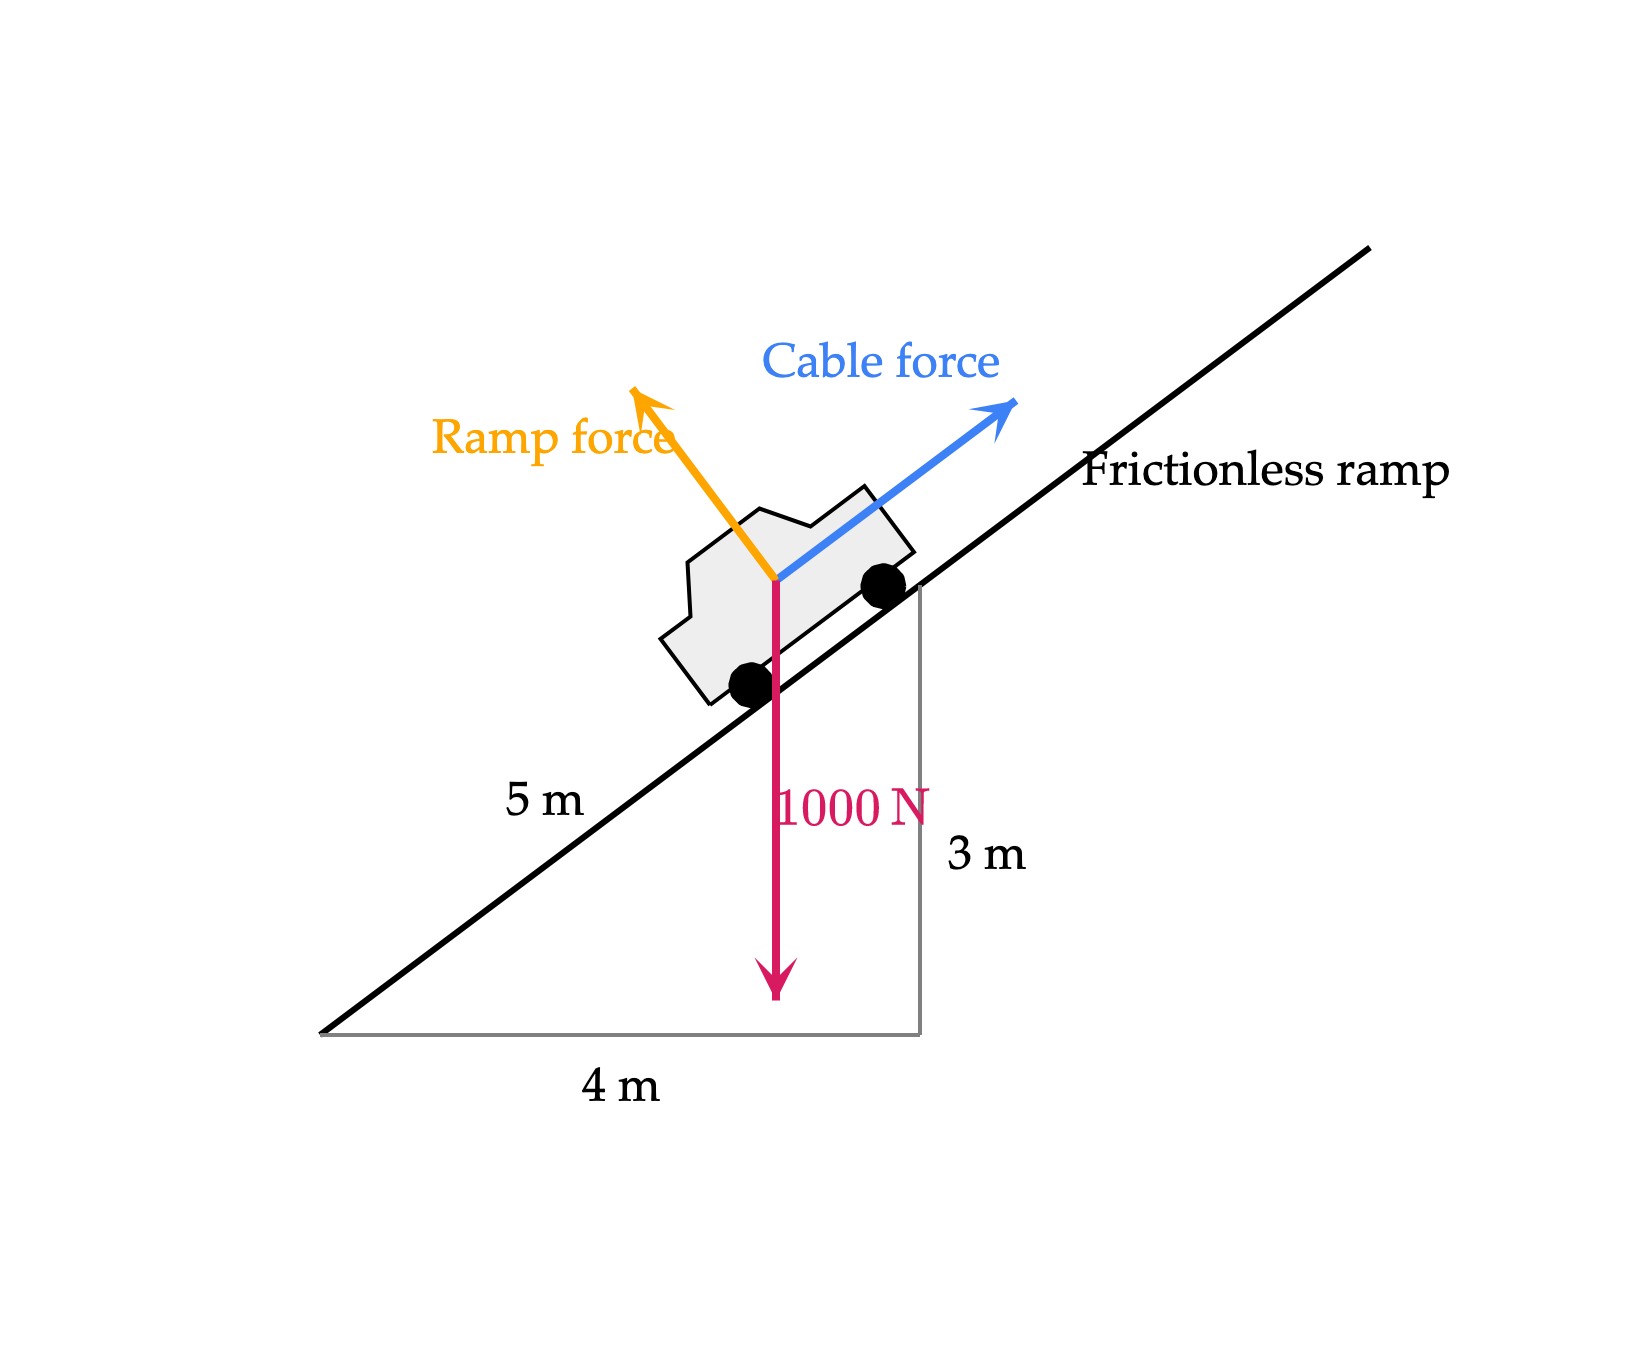

In [5]:
fig=base2((-1,8),(-1.5,6.5),width=820,height=680)
fig.update_xaxes(visible=False); fig.update_yaxes(visible=False)
u=np.array([4/5,3/5]); normal=np.array([-3/5,4/5])
line2(fig,(0,0),(7,5.25),'black',width=3)
line2(fig,(0,0),(4,0),'gray'); line2(fig,(4,0),(4,3),'gray')
label2(fig,(2,-0.35),'4 m'); label2(fig,(4.45,1.2),'3 m')
label2(fig,(1.5,1.55),'5 m')
anchor=np.array([3.4,2.55])
def vehicle_points(points):
    points=np.asarray(points)
    return anchor+points[:,0,None]*u+points[:,1,None]*normal
body=vehicle_points([[-0.85,0.2],[0.85,0.2],[0.85,0.75],[0.4,0.75],[0.2,1.05],[-0.4,1.05],[-0.6,0.75],[-0.85,0.75],[-0.85,0.2]])
fig.add_trace(go.Scatter(x=body[:,0],y=body[:,1],mode='lines',fill='toself',fillcolor='#eeeeee',line=dict(color='black',width=2)))
for along in [-0.55,0.55]:
    center=anchor+along*u+0.14*normal
    t=np.linspace(0,2*np.pi,60)
    fig.add_trace(go.Scatter(x=center[0]+0.14*np.cos(t),y=center[1]+0.14*np.sin(t),mode='lines',fill='toself',fillcolor='black',line=dict(color='black')))
start=anchor+0.6*normal
vec2(fig,start+2*u,'Cable force',BLUE,start=start,dx=-0.1,dy=0.85)
vec2(fig,start+1.6*normal,'Ramp force',ORANGE,start=start,dx=-1.0,dy=0.3)
vec2(fig,start+np.array([0,-2.8]),r'$1000\text{ N}$',PINK,start=start,dx=0.5,dy=-0.1)
label2(fig,(6.3,3.75),'Frictionless ramp')
fig.show(scale=2)

```{figure} #plot-23-ramp
:label: fig-plot-23-ramp
:class: course-caption
:alt: The cable pulls uphill, the ramp pushes perpendicular to its surface, and gravity acts vertically downward. Force-arrow lengths are schematic.

The cable pulls uphill, the ramp pushes perpendicular to its surface, and gravity acts vertically downward. Force-arrow lengths are schematic.
```

The cable must exert **$600$ N up the ramp**. To see why, we'll resolve gravity into components parallel and perpendicular to the ramp.

Use horizontal–vertical coordinates, with positive $y$ pointing upward. The gravitational force is

$$\vec F_g=\begin{bmatrix}0\\-1000\end{bmatrix}\text{ N}.$$

The ramp's direction comes from a $3$–$4$–$5$ triangle, so a unit vector pointing uphill is

$$\vec u=\begin{bmatrix}4/5\\3/5\end{bmatrix}.$$

Let $\ell=\operatorname{span}(\vec u)$ be the line through the origin parallel to the ramp. Projecting gravity onto this direction gives

$$\begin{aligned}
\vec F_{g,\parallel}
&=(\vec F_g\cdot\vec u)\vec u\\
&=\left(0\left(\frac45\right)-1000\left(\frac35\right)\right)\vec u\text{ N}\\
&=-600\vec u\text{ N}\\
&=\begin{bmatrix}-480\\-360\end{bmatrix}\text{ N}.
\end{aligned}$$

The negative sign means this component points **downhill**, opposite to $\vec u$. Since $\vec u$ has length one, the component has magnitude $600$ N. The cable must balance it by pulling uphill:

$$\vec F_c=600\vec u\text{ N}=\begin{bmatrix}480\\360\end{bmatrix}\text{ N}.$$

We can get the same projection without normalizing, using $\vec v_1=\begin{bmatrix}4\\3\end{bmatrix}$:

$$\vec F_{g,\parallel}=\frac{0(4)-1000(3)}{4^2+3^2}\begin{bmatrix}4\\3\end{bmatrix}\text{ N}=-120\begin{bmatrix}4\\3\end{bmatrix}\text{ N}=\begin{bmatrix}-480\\-360\end{bmatrix}\text{ N}.$$

The same $600$ N cable force also lets the vehicle move at constant speed along the straight ramp, since the net force is zero.

:::{note} Why doesn’t the vehicle move into the ramp?
:class: dropdown

What balances the rest of gravity? Its perpendicular component is

$$\vec F_{g,\perp}=\vec F_g-\vec F_{g,\parallel}=\begin{bmatrix}480\\-640\end{bmatrix}\text{ N}.$$

This component pushes into the ramp. The ramp supplies an equal and opposite **normal force**:

$$\vec F_N=\begin{bmatrix}-480\\640\end{bmatrix}\text{ N},\qquad\lVert\vec F_N\rVert=800\text{ N}.$$

Because the ramp is frictionless, its contact force has no component along the ramp. The cable balances gravity along the ramp, while the normal force balances gravity perpendicular to it. Together,

$$\vec F_g+\vec F_c+\vec F_N=\begin{bmatrix}0\\-1000\end{bmatrix}+\begin{bmatrix}480\\360\end{bmatrix}+\begin{bmatrix}-480\\640\end{bmatrix}=\begin{bmatrix}0\\0\end{bmatrix}\text{ N}.$$
:::
